In [1]:
%load_ext autoreload
%autoreload 2

In [42]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata
import joblib
from tqdm import tqdm
import seaborn as sns
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from dataclasses import dataclass
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pyproj import Transformer

sns.set_theme()

In [43]:
from utils.site import Site
from utils.tree import Tree
from utils.constants import (
    GH_ASHANTI_GDF,
    ETHZ_COCOA_MAP_THRESHOLDED_FILEPATH,
    ETHZ_COCOA_MAP_FILEPATH,
    SILVER_FOLDERPATH,
    ETHZ_COCOA_MAP_UINT8_FILEPATH,
    SENTINEL_SCENES_FOLDERPATH,
)

In [44]:
# Load sites
sites = joblib.load(SILVER_FOLDERPATH / "enriched-sites.pkl")
print(f"Loaded {len(sites)} sites")

Loaded 155 sites


In [45]:
# Generate random points across Ghana
N_POINTS = 10_000

ghana_metric = GH_ASHANTI_GDF.to_crs(epsg=32630)

# Get ghana boundary
ghana_poly = ghana_metric.union_all()
min_x, min_y, max_x, max_y = ghana_poly.bounds

random_points = []

# Vectorized rejection sampling loop for speed
while len(random_points) < N_POINTS:
    # Generate a buffer batch of points to minimize looping overhead
    batch_size = (N_POINTS - len(random_points)) * 2

    xs = np.random.uniform(min_x, max_x, batch_size)
    ys = np.random.uniform(min_y, max_y, batch_size)

    # Create shapely Point objects
    possible_points = [Point(x, y) for x, y in zip(xs, ys)]

    # Keep only points that fall inside the actual shape of Ghana
    valid_points = [p for p in possible_points if ghana_poly.contains(p)]

    random_points.extend(valid_points)

# Trim down to exactly 10,000 in case the last batch overshot
random_points = random_points[:N_POINTS]

# Create a new GeoDataFrame and project back to WGS84 (Lat/Lon)
random_points_gdf = gpd.GeoDataFrame(geometry=random_points, crs=ghana_metric.crs)
random_points_gdf = random_points_gdf.to_crs(epsg=4326)
random_points_gdf["lon"] = random_points_gdf.geometry.x
random_points_gdf["lat"] = random_points_gdf.geometry.y
random_points_gdf["lonlat"] = random_points_gdf.apply(lambda row: (row["lon"], row["lat"]), axis=1)

print(f"Generated {len(random_points_gdf)} valid random points inside Ghana.")

Generated 10000 valid random points inside Ghana.


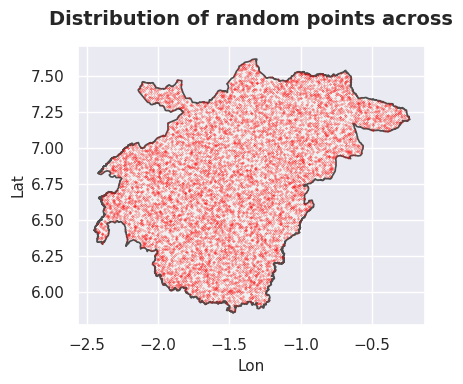

In [46]:
# Plot our random samples
def plot_map(gdf: gpd.GeoDataFrame, point_gdf: gpd.GeoDataFrame) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    gdf.plot(ax=ax, color="#f0f0f0", edgecolor="#4d4d4d", linewidth=1.2)
    point_gdf.plot(ax=ax, color="RED", markersize=0.05, alpha=0.8)
    
    ax.set_title("Distribution of random points across", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Lon", fontsize=11)
    ax.set_ylabel("Lat", fontsize=11)
    
    plt.tight_layout()
    plt.show()

plot_map(GH_ASHANTI_GDF, random_points_gdf)

In [47]:
@dataclass
class Location:
    lonlat: tuple[float, float]

    red: float | None = None
    rededge: float | None = None
    blue: float | None = None
    green: float | None = None
    nir: float | None = None
    swir: float | None = None

    @property
    def ndvi(self) -> np.ndarray:
        """Normalized Difference Vegetation Index"""
        return (self.nir - self.red) / (self.nir + self.red)

    @property
    def tci(self) -> np.ndarray:
        """Triangular Chlorophyll Index"""
        return 1.2 * (self.red_edge - self.green) - 1.5 * (self.red - self.green) * np.sqrt(self.red_edge / self.red)


locations = [Location(lonlat=(e)) for e in random_points_gdf.lonlat]
print(f"# Random locations: {len(locations)}")

# Random locations: 10000


In [48]:
# Plot all sentinel patches

@dataclass
class Bbox:
    bbox: rasterio.coords.BoundingBox
    crs: None

def load_bbox(raster_folderpath: Path) -> Bbox:
    bounds = []
    crss = []
    for suffix in ["_red", "_blue", "_green", "_nir", "_swir22", "_rededge1"]:
        with rasterio.open(fp / f"{fp.name}{suffix}.tif") as src:
            bounds.append(src.bounds)
            crss.append(src.crs)

    if not all(b == bounds[0] for b in bounds):
        raise ValueError()

    if not all(e == crss[0] for e in crss):
        raise ValueError()
    
    return Bbox(bbox=bounds[0], crs=crss[0])
    
fps = list(SENTINEL_SCENES_FOLDERPATH.glob("S2B_*_2020*"))

bboxes = []
for fp in fps:
    bboxes.append(load_bbox(fp))

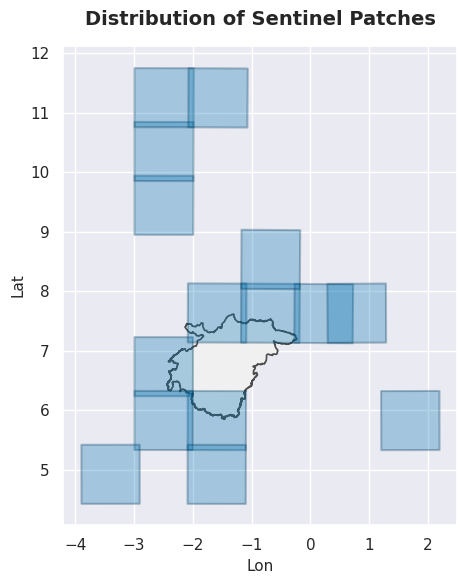

In [50]:
def plot_sentinel_patches(gdf: gpd.GeoDataFrame, bounds: list[rasterio.coords.BoundingBox]) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot base region
    gdf.plot(ax=ax, color="#f0f0f0", edgecolor="#4d4d4d", linewidth=1.2)
    
    # Bounds -> gdf
    for b in bboxes:
        poly = box(b.bbox.left, b.bbox.bottom, b.bbox.right, b.bbox.top)
        bounds_gdf = gpd.GeoDataFrame({"geometry": [poly]}, crs=b.crs)
        
        # Reproject patch_gdf to match the base gdf CRS if necessary
        if bounds_gdf.crs != gdf.crs:
            bounds_gdf = bounds_gdf.to_crs(gdf.crs)
            
        # Plot Sentinel patches as semi-transparent squares
        bounds_gdf.plot(ax=ax, color="#0072B2", edgecolor="#003554", alpha=0.3, linewidth=1.5)
    
    ax.set_title("Distribution of Sentinel Patches", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Lon", fontsize=11)
    ax.set_ylabel("Lat", fontsize=11)
    
    plt.tight_layout()
    plt.show()

plot_sentinel_patches(GH_ASHANTI_GDF, bboxes)

In [32]:
# Load -- for the random points -- the 2020 sentinel data
def get_values(raster_filepath: Path, lonlats: list[tuple[float, float]]) -> list[float | None]:
    values = []
    with rasterio.open(raster_filepath) as src:
        transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        xys = [transformer.transform(lon, lat) for lon, lat in lonlats]

        for val in src.sample(xys):
            if val[0] == src.nodata:
                values.append(None)
            else:
                # val comes back as an array matching the number of bands in the TIFF
                values.append(float(val[0]))

    return values

In [ ]:
# Consider all 2020 sentinel data
fps = list(SENTINEL_SCENES_FOLDERPATH.glob("S2B_*_2020*"))

lonlats = [e.lonlat for e in locations]

reds, blues, greens, nirs, swirs, rededges = [], [], [], [], [], []
for fp in tqdm(fps, total=len(fps)):
    reds.append(get_values(fp / f"{fp.name}_red.tif", lonlats))
    blues.append(get_values(fp / f"{fp.name}_blue.tif", lonlats))
    greens.append(get_values(fp / f"{fp.name}_green.tif", lonlats))
    nirs.append(get_values(fp / f"{fp.name}_nir.tif", lonlats))
    swirs.append(get_values(fp / f"{fp.name}_swir22.tif", lonlats))
    rededges.append(get_values(fp / f"{fp.name}_rededge1.tif", lonlats))

In [41]:
# Enrich the locations
for l, red, blue, green, nir, swir, rededge in zip(locations, reds, blues, greens, nirs, swirs, rededges):
    if red is not None:
        l.red = red

    if blue is not None:
        l.blue = blue

    if green is not None:
        l.green = green

    if nir is not None:
        l.nir = nir

    if rededge is not None:
        l.rededge = rededge

    if swir is not None:
        l.swir = swir

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:06<00:00,  2.16it/s]


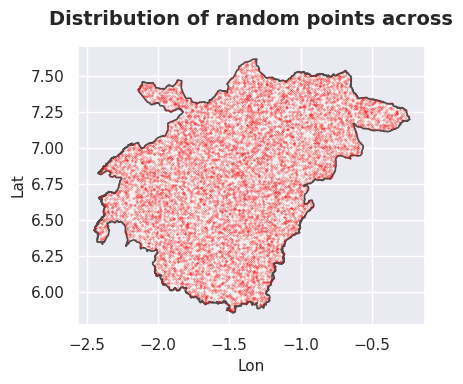

In [39]:
plot_map(GH_ASHANTI_GDF, gpd.GeoDataFrame(geometry=[Point(e.lonlat[0], e.lonlat[1]) for e in locations], crs=locations[0].crs))

In [14]:
locations

[Location(lonlat=(-2.3994314920426, 10.890951198530175), red=1, rededge=None, blue=None, green=None, nir=None, swir=None),
 Location(lonlat=(-0.8941607080567314, 10.841291226037269), red=1, rededge=None, blue=None, green=None, nir=None, swir=None),
 Location(lonlat=(-2.2322600807061006, 10.624651254963114), red=1, rededge=None, blue=None, green=None, nir=None, swir=None),
 Location(lonlat=(-1.0596864906340833, 10.04860398626814), red=1, rededge=None, blue=None, green=None, nir=None, swir=None),
 Location(lonlat=(0.20092234898438627, 7.557989186470963), red=1, rededge=None, blue=None, green=None, nir=None, swir=None),
 Location(lonlat=(-2.8397242837942835, 7.318581218782481), red=1, rededge=None, blue=None, green=None, nir=None, swir=None),
 Location(lonlat=(-0.18361205161608518, 5.62595142517454), red=1, rededge=None, blue=None, green=None, nir=None, swir=None),
 Location(lonlat=(-1.8932907531250942, 6.465354966035802), red=1, rededge=None, blue=None, green=None, nir=None, swir=None),


In [123]:
locations[1]

Location(lonlat=(-0.44300968638800725, 7.889732767694744), red=None, rededge=None, blue=None, green=None, nir=None, swir=None)

In [5]:
# Figure out all locations of interests
lat_lons = []
for s in sites:
    lat_lons += s.lat_lons
lon_lats = [(lon, lat) for lat, lon in lat_lons]

In [20]:
lonlat_to_val = {}

with rasterio.open(ETHZ_COCOA_MAP_FILEPATH) as src:
    print(f"Raster CRS: {src.crs}")

    for lon_lat, val in zip(lon_lats, src.sample(lon_lats)):
        # val comes back as an array matching the number of bands in the TIFF
        lonlat_to_val[lon_lat] = float(val[0])

Raster CRS: EPSG:4326


Text(0.5, 1.0, 'ETHZ-probs histogram of the max-pooling-amongst-trees for each 155 site')

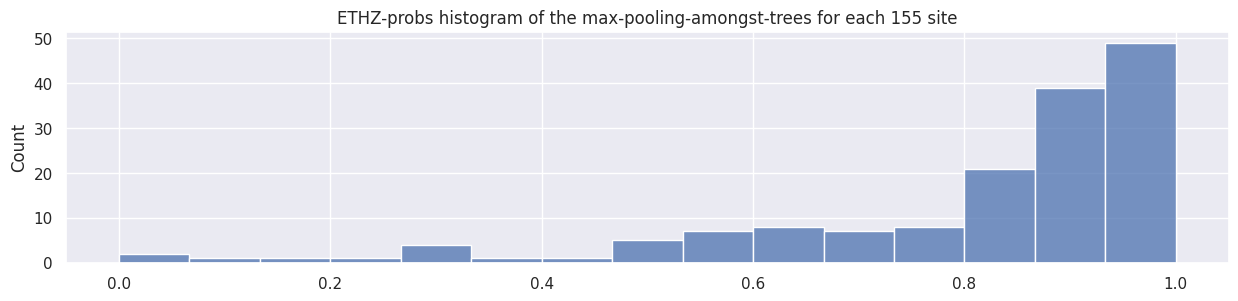

In [31]:
site_name_to_probs = {}
for s in sites:
    probs = []
    for lat, lon in s.lat_lons:
        probs.append(lonlat_to_val[(lon, lat)])
    site_name_to_probs[s.name] = probs

plt.figure(figsize=(15, 3))
sns.histplot([max(e) for e in site_name_to_probs.values()])
plt.title(f"ETHZ-probs histogram of the max-pooling-amongst-trees for each {len(sites)} site")

In [38]:
for site_name, probs in site_name_to_probs.items():
    if max(probs) > 0.2:
        continue
    print(site_name, max(probs))

DU03 0.13958334922790527
KU06 0.0
KU13 0.018518507480621338
SB13 0.07147949934005737
